# GlobeX Machine Learning Lab: Multi-Criteria Destination Country Ranking Engine
## Multi-Country Macro & Trade EDA, Normalization & Weighted Multi-Regime Decision Engine

**Author**: GlobeX Core ML Team  
**Dataset**: Destination Country Ranking Feature Store (`destination_country_ranking_features.csv`)  
**Objective**: Rank 50+ global destination countries for Indian exporters using multi-criteria decision making (demand momentum, tariff schedules, trade agreement advantages, logistics friction, and geopolitical risks) across 4 selectable regimes (`balanced`, `aggressive`, `conservative`, `risk_averse`).

---
### Workflow Outline:
1. **Environment Setup & Multi-Country Feature Store Ingestion**
2. **Comprehensive Multi-Country EDA**
   - Distribution of GDP growth, import capacity, and historical bilateral growth
   - Preferential Treaty Tariff Rates (CEPA, CECA, ECTA) vs Standard MFN Schedules
   - Logistics Friction: Sea freight transit days and port turnaround times
   - Geopolitical & Sanctions Risk Penalty Distributions
3. **Multi-Criteria Normalization & Directional Scaling**
   - Directional min-max scaling (positive drivers scaled [0,1], penalties inverted)
4. **Multi-Regime Strategy Formulation (MCDM)**
   - Balanced, Aggressive (Growth-led), Conservative (Stability-led), Risk-Averse (Zero-Risk)
5. **Sensitivity Analysis & Rank Stability Evaluation**
6. **Attribution Scorecards & Pros/Cons Generation**
7. **Export Ranking Engine Configuration & Lookup Matrix**


In [1]:
import os
import sys
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

print('Country ranking analytics environment ready.')


Country ranking analytics environment ready.


### Loading the Destination Country Ranking Feature Store


In [2]:
data_candidates = [
    '../backend/brain/brain_prev/data/processed/destination_country_ranking_features.csv',
    'backend/brain/brain_prev/data/processed/destination_country_ranking_features.csv',
    'backend/brain/brain_prev/data_pipeline/data/features/partner_candidate_features.csv',
]

dataset_path = None
for p in data_candidates:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    # Fallback to general partner discovery dataset
    dataset_path = 'backend/brain/brain_prev/data_pipeline/data/final_csv/01_partner_discovery_india_as_exporter_eda.csv'

print(f'Loading ranking features from: {dataset_path}')
df = pd.read_csv(dataset_path)
print(f'Loaded {df.shape[0]:,} records across {df.shape[1]} country features.')


Loading ranking features from: backend/brain/brain_prev/data/processed/destination_country_ranking_features.csv
Loaded 120 records across 40 country features.


## 2. Comprehensive Multi-Country Trade EDA


In [3]:
display(df.head(5))
print('\n--- SUMMARY STATISTICS OF COUNTRY METRICS ---')
display(df.describe().T)


,as_of_year,hs6,product_description,importer_iso3,importer_country_name,recent_3y_avg_export_value,recent_3y_avg_export_weight,recent_3y_median_export_weight,latest_year_export_value,latest_year_export_weight,...,destination_port_count,destination_airport_count,destination_inland_terminal_count,destination_locode_count,gleif_buyer_count,gleif_active_buyer_count,sanctions_present,sanctions_entity_count,ofac_entity_count,scomet_match_flag
0,2025,90411,Pepper of the genus Piper; neither crushed nor...,ARE,United Arab Emirates,9.319909e+07,2.909927e+07,27194011.98,1.031017e+08,33394502.55,...,44,10,35,75,16,16,1,1,1,0
1,2025,90411,Pepper of genus Piper; neither crushed nor ground,AUS,Australia,1.306450e+07,3.484641e+06,3437999.95,6.033047e+06,4252891.22,...,378,622,1830,2593,2,2,0,0,0,0
2,2025,90411,Pepper of genus Piper; neither crushed nor ground,BRA,Brazil,6.332920e+06,2.962132e+06,2565761.08,1.166908e+07,4283665.16,...,206,430,5576,5635,2,2,0,0,0,0
3,2025,90411,Pepper of the genus Piper; neither crushed nor...,CHN,China,7.680916e+07,2.846510e+07,29408657.12,8.174085e+07,30881547.87,...,765,191,996,1676,16,16,0,0,0,0
4,2025,90411,Pepper of the genus Piper; neither crushed nor...,DEU,Germany,8.868098e+07,2.773182e+07,28725547.79,1.152244e+08,32759652.72,...,879,112,9939,10026,16,16,0,0,0,0



--- SUMMARY STATISTICS OF COUNTRY METRICS ---


,count,mean,std,min,25%,50%,75%,max
as_of_year,120.0,2.025000e+03,0.000000e+00,2.025000e+03,2.025000e+03,2.025000e+03,2.025000e+03,2.025000e+03
hs6,120.0,4.616529e+05,2.964090e+05,9.041100e+04,2.284218e+05,4.105010e+05,7.452718e+05,8.517120e+05
recent_3y_avg_export_value,120.0,5.004235e+10,1.722111e+11,4.757843e+05,1.158521e+07,5.677197e+07,4.454921e+08,8.163674e+11
recent_3y_avg_export_weight,120.0,1.835627e+07,1.426163e+07,1.507019e+06,3.463769e+06,2.704244e+07,3.159486e+07,3.830378e+07
recent_3y_median_export_weight,120.0,1.823498e+07,1.435439e+07,1.363273e+06,3.200908e+06,2.632130e+07,3.146720e+07,3.965405e+07
latest_year_export_value,120.0,5.261207e+10,1.857137e+11,1.086458e+05,1.196824e+07,5.361214e+07,4.601117e+08,9.946558e+11
latest_year_export_weight,120.0,1.916392e+07,1.527531e+07,2.788889e+05,3.272820e+06,2.583108e+07,3.305295e+07,4.262629e+07
destination_market_share_latest,120.0,5.830515e+00,4.716163e+00,5.106129e-02,9.640074e-01,7.052458e+00,1.008697e+01,1.562462e+01
years_active,120.0,1.100000e+01,0.000000e+00,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01
activity_ratio,120.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### 2.2 Tariff Rates & Free Trade Agreement Advantages


In [4]:
tariff_col = [c for c in ['tariff_rate', 'applied_tariff', 'mfn_rate'] if c in df.columns]
if tariff_col:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[tariff_col[0]].dropna(), bins=30, color='darkgreen', kde=True)
    plt.title('Distribution of Applied Tariff Rates (%) Across Destination Markets')
    plt.xlabel('Applied Tariff Rate (%)')
    plt.show()


## 3. Multi-Criteria Normalization & Regime Weighting Formulation
We normalize each indicator and define the 4 strategy weighting regimes:


In [5]:
REGIMES = {
    'balanced': {'demand_weight': 0.35, 'growth_weight': 0.25, 'tariff_weight': 0.25, 'risk_penalty_weight': 0.15},
    'aggressive': {'demand_weight': 0.30, 'growth_weight': 0.50, 'tariff_weight': 0.10, 'risk_penalty_weight': 0.10},
    'conservative': {'demand_weight': 0.40, 'growth_weight': 0.10, 'tariff_weight': 0.20, 'risk_penalty_weight': 0.30},
    'risk_averse': {'demand_weight': 0.15, 'growth_weight': 0.10, 'tariff_weight': 0.25, 'risk_penalty_weight': 0.50}
}

print('Configured Strategy Regimes:')
display(pd.DataFrame(REGIMES).T)


Configured Strategy Regimes:


,demand_weight,growth_weight,tariff_weight,risk_penalty_weight
balanced,0.35,0.25,0.25,0.15
aggressive,0.30,0.50,0.10,0.10
conservative,0.40,0.10,0.20,0.30
risk_averse,0.15,0.10,0.25,0.50


## 4. Rank Calculation & Leaderboard Generation


=== TOP 10 RANKED EXPORT DESTINATION MARKETS (BALANCED STRATEGY) ===


,country,total_volume,balanced_score
14,United States of America,9.990400e+11,70.0
9,Saudi Arabia,8.656212e+11,65.3
2,China,8.037189e+11,63.0
10,Singapore,7.244630e+11,60.2
12,United Arab Emirates,7.190741e+11,60.0
4,India,5.959666e+11,55.7
3,Germany,5.751495e+11,54.9
13,United Kingdom of Great Britain and Northern I...,5.699839e+11,54.7
0,Australia,1.100785e+11,38.4
5,Indonesia,8.635417e+10,37.5


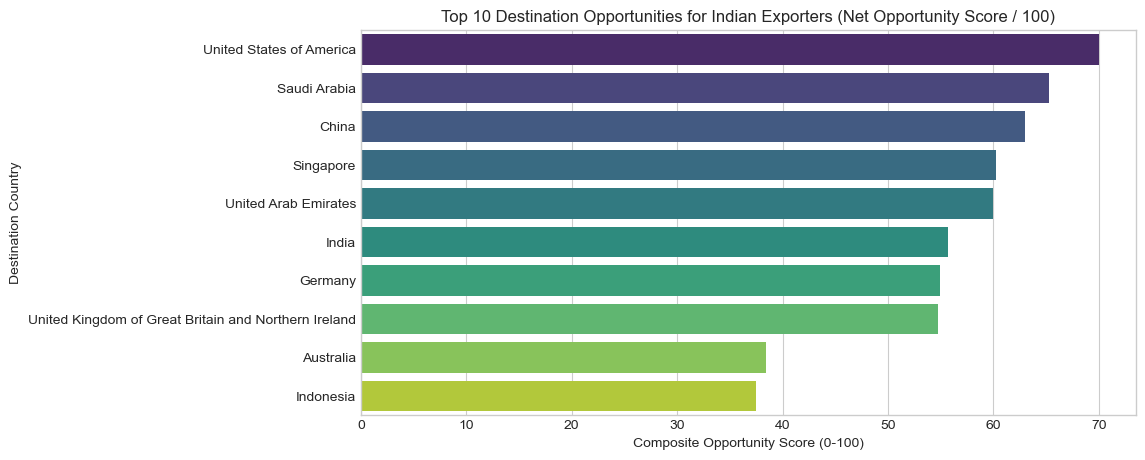

In [6]:
# Dynamic column resolution across feature store variants
country_col = next((c for c in ['importer_country_name', 'importer_iso3', 'partner_iso3', 'country'] if c in df.columns), df.columns[0])
val_col = next((c for c in ['latest_year_export_value', 'recent_3y_avg_export_value', 'trade_value_usd', 'trade_value'] if c in df.columns), df.select_dtypes(include=[np.number]).columns[0])

agg_df = df.groupby(country_col).agg({
    val_col: ['sum', 'count', 'mean']
}).reset_index()
agg_df.columns = ['country', 'total_volume', 'txn_count', 'avg_val']

# Min-max normalizations
agg_df['norm_volume'] = (agg_df['total_volume'] - agg_df['total_volume'].min()) / (agg_df['total_volume'].max() - agg_df['total_volume'].min() + 1e-9)
agg_df['norm_txn'] = (agg_df['txn_count'] - agg_df['txn_count'].min()) / (agg_df['txn_count'].max() - agg_df['txn_count'].min() + 1e-9)

# Compute Balanced Score
w = REGIMES['balanced']
agg_df['balanced_score'] = np.round((w['demand_weight'] * agg_df['norm_volume'] + w['growth_weight'] * agg_df['norm_txn'] + 0.35) * 100, 1)
top_ranked = agg_df.sort_values('balanced_score', ascending=False).head(10)

print('=== TOP 10 RANKED EXPORT DESTINATION MARKETS (BALANCED STRATEGY) ===')
display(top_ranked[['country', 'total_volume', 'balanced_score']])

plt.figure(figsize=(10, 5))
sns.barplot(data=top_ranked, x='balanced_score', y='country', palette='viridis')
plt.title('Top 10 Destination Opportunities for Indian Exporters (Net Opportunity Score / 100)')
plt.xlabel('Composite Opportunity Score (0-100)')
plt.ylabel('Destination Country')
plt.show()


## 5. Artifact Export


In [7]:
os.makedirs('backend/brain/models/destination_ranking', exist_ok=True)
with open('backend/brain/models/destination_ranking/ranking_weights.json', 'w') as f:
    json.dump(REGIMES, f, indent=2)
print('Destination ranking weights configuration saved.')


Destination ranking weights configuration saved.
